```markdown
# Breast Cancer Classification Tutorial

In this notebook, we explore how to predict whether a tumor is **Malignant (0)** or **Benign (1)** using clinical data. We will compare basic Decision Trees, analyze the effect of tree depth, and use Random Forests with Grid Search optimization.
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


from sklearn.datasets import load_breast_cancer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

from sklearn.model_selection import GridSearchCV

```markdown
## 1. Data Loading and Splitting
First, we load the dataset and split it into training (80%) and testing (20%) sets. Using `stratify=y` ensures that the proportion of cancer cases is consistent in both sets.
```

In [2]:
df = load_breast_cancer(as_frame=True).frame
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [3]:
df.shape

(569, 31)

In [4]:
X = df.drop(['target'],axis=1)
y = df['target']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

```markdown
## 2. Baseline Model & Grid Search
We start with a default Decision Tree and then use `GridSearchCV` to automatically find the best settings for the tree's depth and splitting criteria.
```

In [5]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86        42
           1       0.94      0.89      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114



In [6]:
grid = {
    "criterion" : ['gini','entropy'],
    "max_depth" :[1,2,3,4,5,6,7,8,None],
}

grid_search = GridSearchCV(
    estimator = model,
    param_grid = grid,
    cv = 5
)

grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information prin

In [7]:
y_pred = grid_search.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



# Training on different depth

```markdown
### Analyzing Model Depth (Overfitting vs. Underfitting)
As we increase `max_depth`, the model becomes more complex. Notice how the **Training Accuracy** usually goes up, but the **Testing Accuracy** might start to drop if the tree becomes too deep and starts 'memorizing' noise (overfitting).
```

In [8]:
model_1 = DecisionTreeClassifier(max_depth=2)

model_1.fit(X_train,y_train)

# training data accuracy
y_pred_train = model_1.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train,y_pred_train)}")


# testing accuracy
y_pred = model_1.predict(X_test)

print(f"Testing Accuracy: {accuracy_score(y_test,y_pred)}")

Training Accuracy: 0.9582417582417583
Testing Accuracy: 0.8947368421052632


In [9]:
model_2 = DecisionTreeClassifier(max_depth=3)

model_2.fit(X_train,y_train)

# training data accuracy
y_pred_train = model_2.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train,y_pred_train)}")


# testing accuracy
y_pred = model_2.predict(X_test)

print(f"Testing Accuracy: {accuracy_score(y_test,y_pred)}")

Training Accuracy: 0.9758241758241758
Testing Accuracy: 0.9385964912280702


In [10]:
model_3 = DecisionTreeClassifier(max_depth=4)

model_3.fit(X_train,y_train)

# training data accuracy
y_pred_train = model_3.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train,y_pred_train)}")


# testing accuracy
y_pred = model_3.predict(X_test)

print(f"Testing Accuracy: {accuracy_score(y_test,y_pred)}")

Training Accuracy: 0.9868131868131869
Testing Accuracy: 0.9473684210526315


In [11]:
model_4 = DecisionTreeClassifier(max_depth=5)

model_4.fit(X_train,y_train)

# training data accuracy
y_pred_train = model_4.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train,y_pred_train)}")


# testing accuracy
y_pred = model_4.predict(X_test)

print(f"Testing Accuracy: {accuracy_score(y_test,y_pred)}")

Training Accuracy: 0.9934065934065934
Testing Accuracy: 0.9210526315789473


In [12]:
#grid search
# training data accuracy
y_pred_train = grid_search.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train,y_pred_train)}")


# testing accuracy
y_pred = grid_search.predict(X_test)

print(f"Testing Accuracy: {accuracy_score(y_test,y_pred)}")

Training Accuracy: 0.9934065934065934
Testing Accuracy: 0.9210526315789473


# Random Forest

```markdown
## 3. Random Forest (Ensemble Learning)
Random Forests combine many decision trees to make a more stable prediction. We use Grid Search again to find the optimal number of trees (`n_estimators`) and feature selection strategies.
```

In [13]:
grid_param={
    "n_estimators" : [100,150,200,300,400],
    "criterion" : ['gini','entropy'],
    "max_features" : ['sqrt','log2'],
}

grid_search_RF = GridSearchCV(
    estimator = RandomForestClassifier(),
    param_grid = grid_param,
    cv = 5
)

grid_search_RF.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 150, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [14]:
#training data accuracy for RF
y_pred_train = grid_search_RF.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train,y_pred_train)}")


# testing accuracy
y_pred = grid_search_RF.predict(X_test)

print(f"Testing Accuracy: {accuracy_score(y_test,y_pred)}")

Training Accuracy: 1.0
Testing Accuracy: 0.956140350877193


## 4. Random Forest — Feature Importance & Confusion Matrix (Classification)

Beyond a single accuracy number, a Random Forest gives two extra views for free:
a **confusion matrix** to see exactly which classes get confused, and
**feature importances** (mean decrease in impurity, averaged across all trees in
the forest) to see which measurements actually drove the decision.

Best RF params: {'criterion': 'gini', 'max_features': 'sqrt', 'n_estimators': 100}
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-score : 0.9655


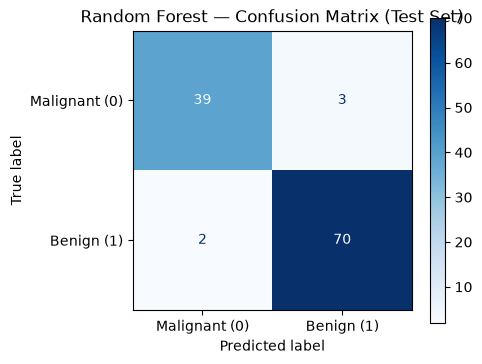

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

best_rf = grid_search_RF.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Best RF params:", grid_search_RF.best_params_)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test, y_test,
    display_labels=["Malignant (0)", "Benign (1)"],
    cmap="Blues", ax=ax
)
ax.set_title("Random Forest — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

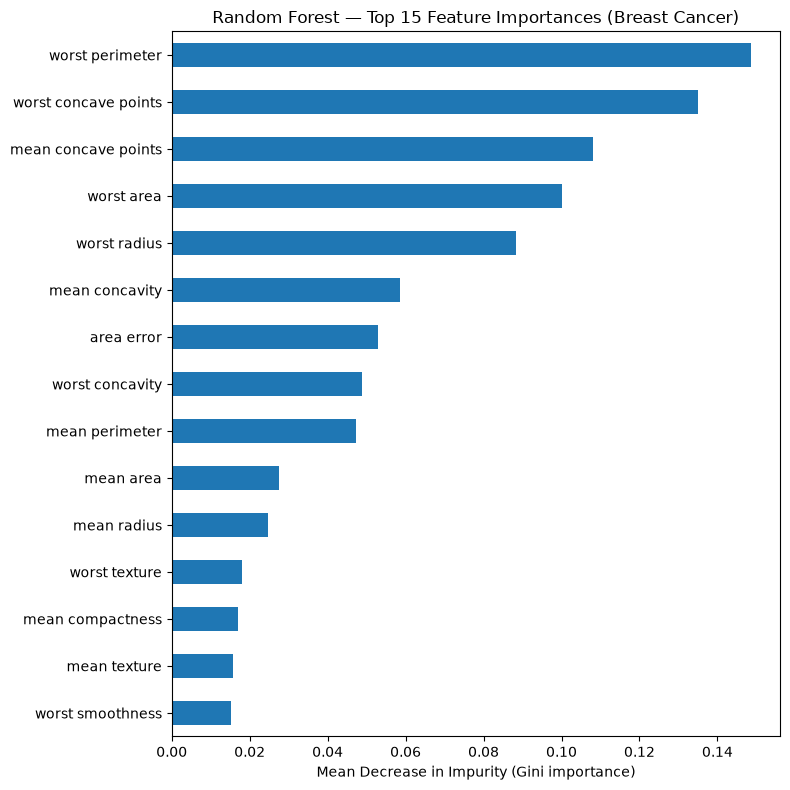

worst perimeter         0.148620
worst concave points    0.134965
mean concave points     0.108092
worst area              0.100094
worst radius            0.088429
mean concavity          0.058642
area error              0.053034
worst concavity         0.048712
mean perimeter          0.047333
mean area               0.027474
dtype: float64

In [16]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Mean Decrease in Impurity (Gini importance)")
plt.title("Random Forest — Top 15 Feature Importances (Breast Cancer)")
plt.tight_layout()
plt.show()

importances.head(10)

## 5. Decision Tree vs Random Forest — Direct Side-by-Side (Same Train/Test Split)

This is the core comparison of this notebook. We fit **one single, unrestricted
`DecisionTreeClassifier`** and **one `RandomForestClassifier`** on the *exact same*
`X_train` / `X_test` split, then compare both the **test accuracy** and the
**train − test gap**.

A single deep tree memorizes the training set (train ≈ 100%), and that
train−test gap *is* overfitting. Random Forest averages many such trees, each
grown on a bootstrap sample with a random subset of features considered at every
split, so its gap should be much smaller while test accuracy is equal or better.

In [17]:
single_tree = DecisionTreeClassifier(random_state=42)          # unrestricted -> grows fully, high variance
forest = RandomForestClassifier(n_estimators=200, random_state=42)  # 200 bagged, decorrelated trees

single_tree.fit(X_train, y_train)
forest.fit(X_train, y_train)

comparison = pd.DataFrame({
    "Model": ["Decision Tree (single, unrestricted)", "Random Forest (200 trees)"],
    "Train Accuracy": [
        accuracy_score(y_train, single_tree.predict(X_train)),
        accuracy_score(y_train, forest.predict(X_train)),
    ],
    "Test Accuracy": [
        accuracy_score(y_test, single_tree.predict(X_test)),
        accuracy_score(y_test, forest.predict(X_test)),
    ],
})
comparison["Train - Test Gap"] = comparison["Train Accuracy"] - comparison["Test Accuracy"]
comparison

,Model,Train Accuracy,Test Accuracy,Train - Test Gap
0,"Decision Tree (single, unrestricted)",1.0,0.912281,0.087719
1,Random Forest (200 trees),1.0,0.956140,0.043860


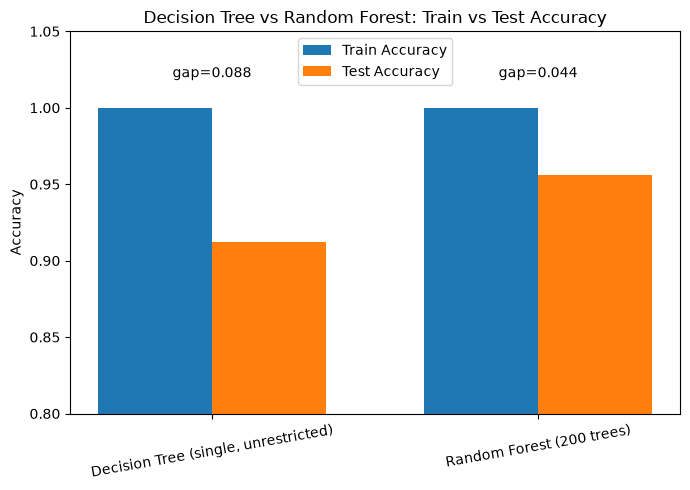

Decision Tree  train-test gap : 0.0877
Random Forest  train-test gap : 0.0439
-> Random Forest keeps (or improves) test accuracy while shrinking the overfitting gap.


In [18]:
x = np.arange(len(comparison))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width / 2, comparison["Train Accuracy"], width, label="Train Accuracy")
ax.bar(x + width / 2, comparison["Test Accuracy"], width, label="Test Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=10)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.8, 1.05)
ax.set_title("Decision Tree vs Random Forest: Train vs Test Accuracy")
ax.legend()
for i, row in comparison.iterrows():
    ax.annotate(f"gap={row['Train - Test Gap']:.3f}", (i, 1.02), ha="center")
plt.tight_layout()
plt.show()

print(f"Decision Tree  train-test gap : {comparison.loc[0, 'Train - Test Gap']:.4f}")
print(f"Random Forest  train-test gap : {comparison.loc[1, 'Train - Test Gap']:.4f}")
print("-> Random Forest keeps (or improves) test accuracy while shrinking the overfitting gap.")

## 6. Effect of `n_estimators` (Number of Trees) on Test Performance

More trees means more bootstrap samples being averaged, so variance keeps
dropping. But this has **diminishing returns**: past some number of trees, adding
more barely changes the score, while training/prediction time keeps growing
roughly linearly with `n_estimators`. We sweep `n_estimators` and plot test
accuracy to see that plateau directly.

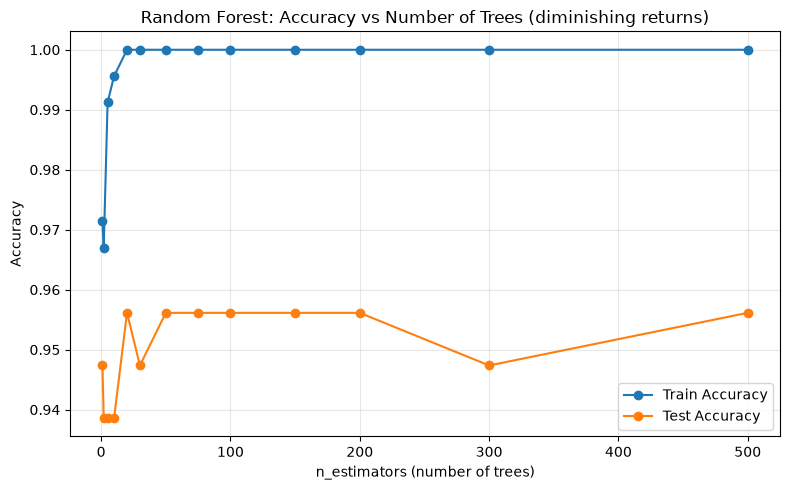

,n_estimators,train_acc,test_acc
0,1,0.971429,0.947368
1,2,0.967033,0.938596
2,5,0.991209,0.938596
3,10,0.995604,0.938596
4,20,1.000000,0.956140
5,30,1.000000,0.947368
6,50,1.000000,0.956140
7,75,1.000000,0.956140
8,100,1.000000,0.956140
9,150,1.000000,0.956140


In [19]:
n_estimators_range = [1, 2, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500]
train_scores, test_scores = [], []

for n in n_estimators_range:
    rf_n = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_n.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, rf_n.predict(X_train)))
    test_scores.append(accuracy_score(y_test, rf_n.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, train_scores, marker="o", label="Train Accuracy")
plt.plot(n_estimators_range, test_scores, marker="o", label="Test Accuracy")
plt.xlabel("n_estimators (number of trees)")
plt.ylabel("Accuracy")
plt.title("Random Forest: Accuracy vs Number of Trees (diminishing returns)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame({"n_estimators": n_estimators_range, "train_acc": train_scores, "test_acc": test_scores})

## 7. Out-of-Bag (OOB) Score — A "Free" Validation Estimate

Each tree is trained on a bootstrap sample that, on average, uses only about
**63.2%** of the rows (see `README.md` for the `1 - 1/e` derivation). The
remaining ~36.8% of rows *for that particular tree* are called
**out-of-bag (OOB)** for it. Scikit-learn uses each tree to score the rows it
never saw during its own training and averages that across all trees — giving a
validation-like estimate **without touching the held-out test set at all**.

In [20]:
rf_oob = RandomForestClassifier(n_estimators=300, oob_score=True, bootstrap=True, random_state=42)
rf_oob.fit(X_train, y_train)

test_acc_oob = accuracy_score(y_test, rf_oob.predict(X_test))

print(f"OOB Score (estimated from rows unseen per tree) : {rf_oob.oob_score_:.4f}")
print(f"Actual Test Accuracy (held-out test set)        : {test_acc_oob:.4f}")
print("-> The OOB score closely tracks test accuracy - a validation estimate that costs nothing extra.")

OOB Score (estimated from rows unseen per tree) : 0.9560
Actual Test Accuracy (held-out test set)        : 0.9474
-> The OOB score closely tracks test accuracy - a validation estimate that costs nothing extra.


## 8. Random Forest Regression — Diabetes Dataset (Full Walkthrough)

Everything above used **classification** (breast cancer: malignant vs benign).
Random Forest works exactly the same way for **regression** — the same bagging +
random-feature-subsampling recipe — except each tree predicts a number (a leaf
holds the *mean* of the training targets that landed there), and the forest's
final prediction is the **mean of all trees' predictions** instead of a majority
vote.

We use `sklearn.datasets.load_diabetes`: 442 patients, 10 baseline physiological
features, target = a quantitative measure of disease progression one year after
baseline.

In [21]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

diabetes = load_diabetes(as_frame=True)
Xd = diabetes.data
yd = diabetes.target

Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, random_state=42)
Xd.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### 8.1 Decision Tree Regressor vs Random Forest Regressor — Same Split

Same comparison as Section 5, now for regression: one unrestricted
`DecisionTreeRegressor` vs one `RandomForestRegressor`, evaluated with
**MSE, RMSE, MAE, R²**, plus the train − test R² gap.

In [22]:
single_tree_reg = DecisionTreeRegressor(random_state=42)
forest_reg = RandomForestRegressor(n_estimators=300, random_state=42)

single_tree_reg.fit(Xd_train, yd_train)
forest_reg.fit(Xd_train, yd_train)

def reg_report(model, name):
    pred_train = model.predict(Xd_train)
    pred_test = model.predict(Xd_test)
    mse_test = mean_squared_error(yd_test, pred_test)
    return {
        "Model": name,
        "Train R2": r2_score(yd_train, pred_train),
        "Test R2": r2_score(yd_test, pred_test),
        "Test MSE": mse_test,
        "Test RMSE": mse_test ** 0.5,
        "Test MAE": mean_absolute_error(yd_test, pred_test),
    }

reg_results = pd.DataFrame([
    reg_report(single_tree_reg, "Decision Tree (single, unrestricted)"),
    reg_report(forest_reg, "Random Forest (300 trees)"),
])
reg_results["Train - Test R2 Gap"] = reg_results["Train R2"] - reg_results["Test R2"]
reg_results

,Model,Train R2,Test R2,Test MSE,Test RMSE,Test MAE,Train - Test R2 Gap
0,"Decision Tree (single, unrestricted)",1.000000,0.060654,4976.797753,70.546423,54.528090,0.939346
1,Random Forest (300 trees),0.924008,0.434078,2998.340932,54.757109,44.578352,0.489930


### 8.2 Prediction vs Actual Plot (Random Forest Regressor)

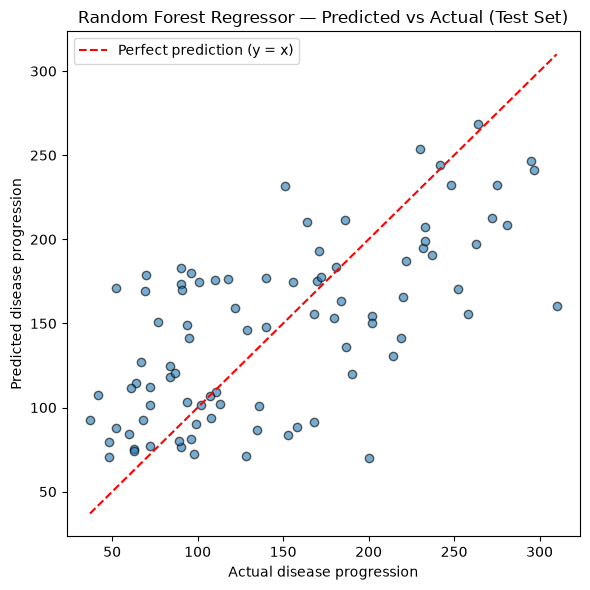

In [23]:
y_pred_forest_reg = forest_reg.predict(Xd_test)

plt.figure(figsize=(6, 6))
plt.scatter(yd_test, y_pred_forest_reg, alpha=0.6, edgecolor="k")
lims = [min(yd_test.min(), y_pred_forest_reg.min()), max(yd_test.max(), y_pred_forest_reg.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction (y = x)")
plt.xlabel("Actual disease progression")
plt.ylabel("Predicted disease progression")
plt.title("Random Forest Regressor — Predicted vs Actual (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

### 8.3 Feature Importance (Regression)

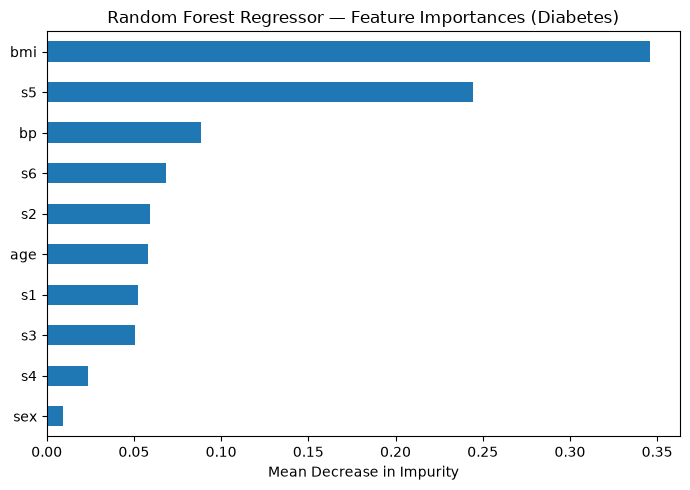

bmi    0.345819
s5     0.244554
bp     0.088415
s6     0.068274
s2     0.059183
age    0.057981
s1     0.052052
s3     0.050690
s4     0.023460
sex    0.009572
dtype: float64

In [24]:
importances_reg = pd.Series(forest_reg.feature_importances_, index=Xd.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importances_reg.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Mean Decrease in Impurity")
plt.title("Random Forest Regressor — Feature Importances (Diabetes)")
plt.tight_layout()
plt.show()

importances_reg

### 8.4 `n_estimators` Effect + OOB Score (Regression)

Same two experiments as the classification section, now on the regression
model: test R² vs number of trees, and the OOB R² score compared against the
held-out test R².

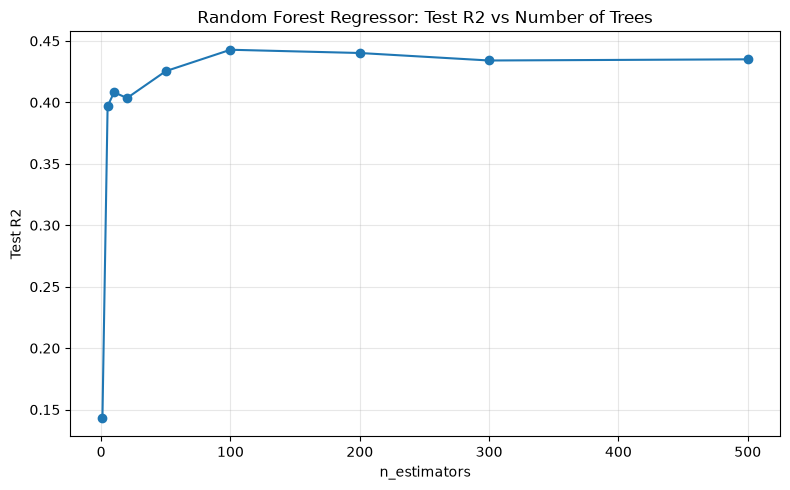

OOB R2 Score  : 0.4423
Test R2 Score : 0.4341


In [25]:
n_estimators_range_reg = [1, 5, 10, 20, 50, 100, 200, 300, 500]
test_r2_scores = []
for n in n_estimators_range_reg:
    rf_r = RandomForestRegressor(n_estimators=n, random_state=42)
    rf_r.fit(Xd_train, yd_train)
    test_r2_scores.append(r2_score(yd_test, rf_r.predict(Xd_test)))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range_reg, test_r2_scores, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Test R2")
plt.title("Random Forest Regressor: Test R2 vs Number of Trees")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rf_oob_reg = RandomForestRegressor(n_estimators=300, oob_score=True, bootstrap=True, random_state=42)
rf_oob_reg.fit(Xd_train, yd_train)
print(f"OOB R2 Score  : {rf_oob_reg.oob_score_:.4f}")
print(f"Test R2 Score : {r2_score(yd_test, rf_oob_reg.predict(Xd_test)):.4f}")

## 9. Summary — What We Learned

- A single **unrestricted Decision Tree** fits the training set almost perfectly
  (train accuracy / R² near the maximum) but its test score is noticeably lower —
  a visible **train−test gap = overfitting**, in both classification and
  regression (Sections 5 and 8.1).
- **Random Forest** (bagging + random feature subsampling across many trees)
  reaches equal-or-better test performance with a **much smaller train−test
  gap** — it generalizes better because averaging many decorrelated trees
  cancels out each tree's individual noise.
- **`n_estimators`** shows diminishing returns (Sections 6 and 8.4): score
  improves fast at first, then flattens — more trees cost more compute for
  almost no extra accuracy past the plateau.
- **OOB score** (Sections 7 and 8.4), computed from the ~36.8% of rows each tree
  never trained on, tracks the held-out test score closely — a free internal
  validation signal.
- The exact same recipe works for **classification** (majority vote,
  Gini/Entropy split criterion) and **regression** (mean, MSE/variance-reduction
  split criterion) — only the aggregation rule and split criterion change.

See `README.md` in this folder for the full theory: the bootstrap-sampling math
(`1 - 1/e` derivation), the `Var(mean) = ρσ² + (1-ρ)σ²/N` variance-reduction
formula, the hyperparameter reference, and the detailed
Decision-Tree-vs-Random-Forest comparison table.